# 1. Project Overview
# 1.1 Introduction
### This project analyzes consumer behavior and purchasing channels using the Consumer Shopping Trends dataset (11,789 records and 25 features).

# 1.2 Problem Statement
### Modern retail environments experience complex shifts in consumer purchasing preferences (divided among online, in-store, and hybrid channels) influenced by demographic details, technological familiarity, financial metrics, and psychological drivers. Without granular analysis and predictive modeling, businesses struggle to accurately anticipate customer channel preferences, optimize inventory across channels, or personalize digital and physical marketing strategies.


## IMPORT LIBRARIES

In [76]:

# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## LOAD DATA USING PANDAS

In [77]:

# =========================================
df = pd.read_csv(r"C:\Users\user\Downloads\sales_trends\Consumer_Shopping_Trends.csv")

In [78]:
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


# Capitalizing columns

In [79]:
df.columns=df.columns.str.capitalize()

In [80]:
df.head()

,Age,Monthly_income,Daily_internet_hours,Smartphone_usage_years,Social_media_hours,Online_payment_trust_score,Tech_savvy_score,Monthly_online_orders,Monthly_store_visits,Avg_online_spend,...,Free_return_importance,Product_availability_online,Impulse_buying_score,Need_touch_feel_score,Brand_loyalty_score,Environmental_awareness,Time_pressure_level,Gender,City_tier,Shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## DATA CLEANING

In [81]:

# =========================================

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
# Numerical → median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 Age                            0
Monthly_income                 0
Daily_internet_hours           0
Smartphone_usage_years         0
Social_media_hours             0
Online_payment_trust_score     0
Tech_savvy_score               0
Monthly_online_orders          0
Monthly_store_visits           0
Avg_online_spend               0
Avg_store_spend                0
Discount_sensitivity           0
Return_frequency               0
Avg_delivery_days              0
Delivery_fee_sensitivity       0
Free_return_importance         0
Product_availability_online    0
Impulse_buying_score           0
Need_touch_feel_score          0
Brand_loyalty_score            0
Environmental_awareness        0
Time_pressure_level            0
Gender                         0
City_tier                      0
Shopping_preference            0
dtype: int64


In [82]:
df.describe()

,Age,Monthly_income,Daily_internet_hours,Smartphone_usage_years,Social_media_hours,Online_payment_trust_score,Tech_savvy_score,Monthly_online_orders,Monthly_store_visits,Avg_online_spend,...,Return_frequency,Avg_delivery_days,Delivery_fee_sensitivity,Free_return_importance,Product_availability_online,Impulse_buying_score,Need_touch_feel_score,Brand_loyalty_score,Environmental_awareness,Time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


## Correlation heatmap

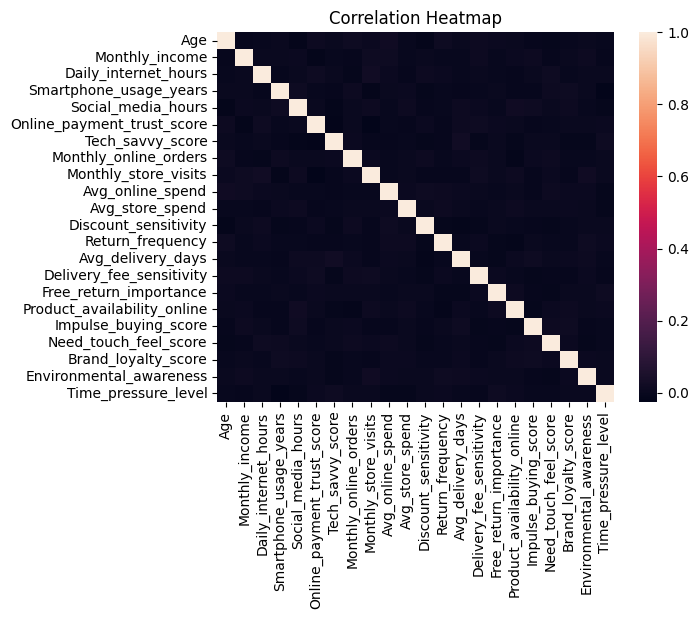

In [ ]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()


# 3. Monthly Income vs. Average Online Spend by Shopping Preference

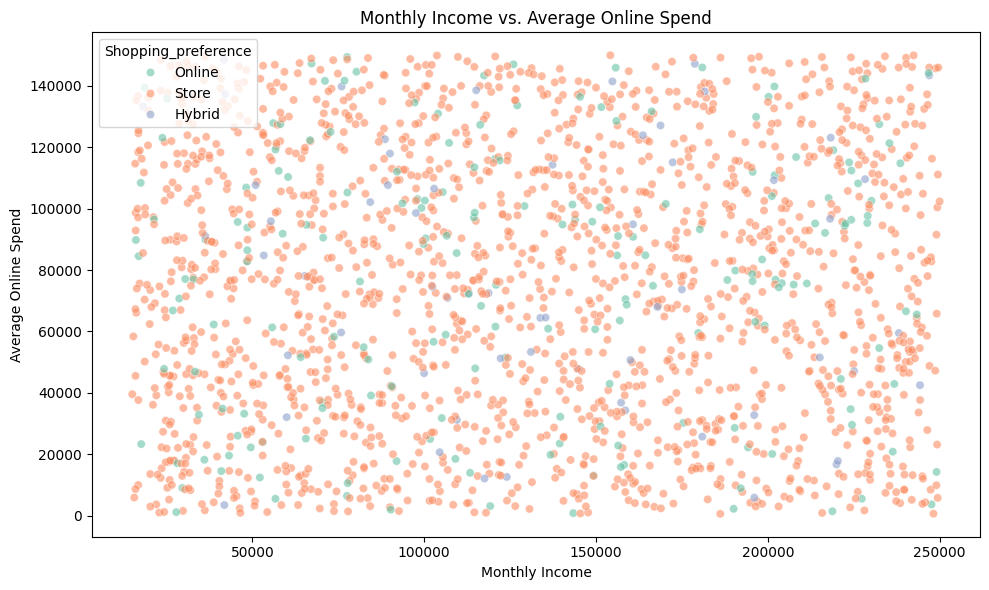

In [84]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(2000, random_state=42),
    x='Monthly_income',
    y='Avg_online_spend',
    hue='Shopping_preference',
    alpha=0.6,
    palette='Set2',
)
plt.title('Monthly Income vs. Average Online Spend')
plt.xlabel('Monthly Income')
plt.ylabel('Average Online Spend')
plt.tight_layout()
plt.show()

# 1. Target Variable Distribution (Shopping Preference)

C:\Users\user\AppData\Local\Temp\ipykernel_4988\1757658817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


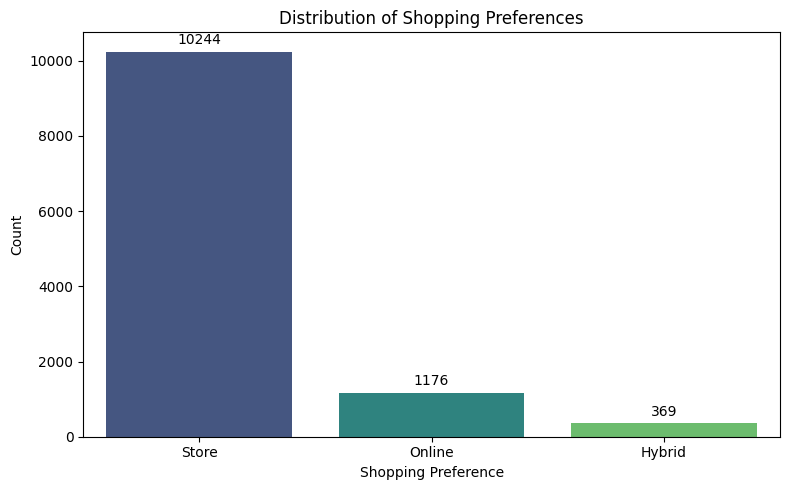

In [85]:

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df, x='Shopping_preference', palette='viridis', order=df['Shopping_preference'].value_counts().index
)
plt.title('Distribution of Shopping Preferences')
plt.xlabel('Shopping Preference')
plt.ylabel('Count')
for p in ax.patches:
  ax.annotate(
      f'{int(p.get_height())}',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='bottom',
      xytext=(0, 3),
      textcoords='offset points',
  )
plt.tight_layout()
plt.show()

# 4. Demographic & Behavioral Distribution (Boxplots)

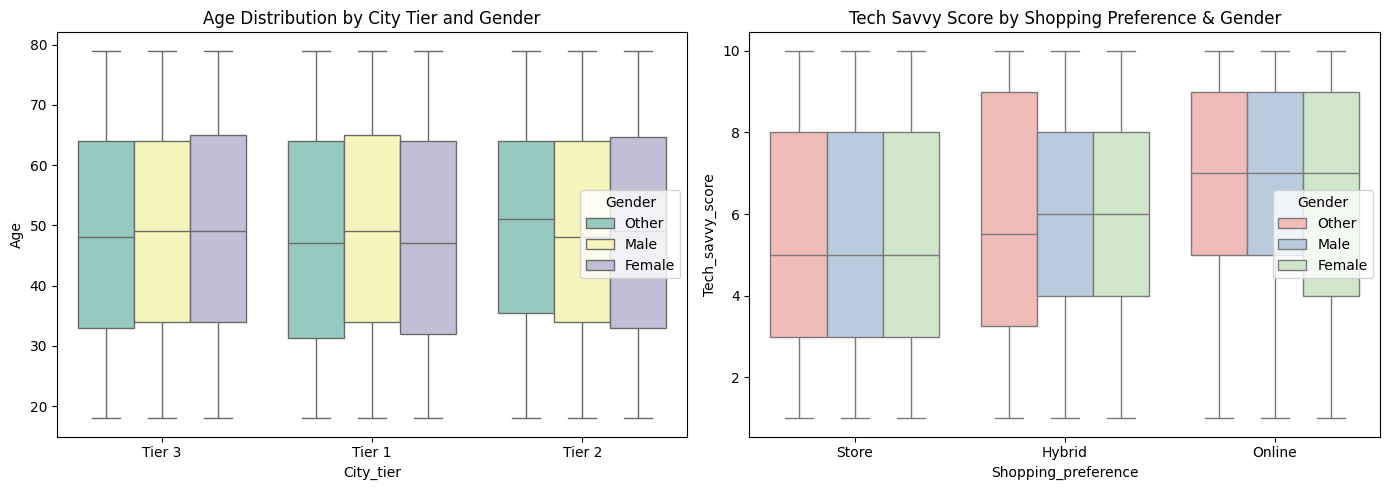

In [86]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=df, x='City_tier', y='Age', hue='Gender', ax=axes[0], palette='Set3'
)
axes[0].set_title('Age Distribution by City Tier and Gender')
sns.boxplot(
    data=df,
    x='Shopping_preference',
    y='Tech_savvy_score',
    hue='Gender',
    ax=axes[1],
    palette='Pastel1',
)
axes[1].set_title('Tech Savvy Score by Shopping Preference & Gender')
plt.tight_layout()
plt.show()

## Convert categorical variables to numeric, and Define features and target

In [87]:

df_encoded = pd.get_dummies(df, drop_first=True)

 
X = df_encoded.drop('Shopping_preference_Store', axis=1)
y = df_encoded['Shopping_preference_Store']

In [88]:
X.shape, y.shape

((11789, 27), (11789,))

## TRAIN-TEST SPLIT

In [89]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## FEATURE SCALING

In [90]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## MACHINE LEARNING MODELS

In [91]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

## TRAINING, PREDICTING, AND EVALUATION

In [92]:

# =========================================
for name, model in models.items():
    print(f"\n{name}")
    print("-" * 30)
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))



Logistic Regression
------------------------------
Accuracy: 0.993214588634436

Confusion Matrix:
 [[ 283   13]
 [   3 2059]]

Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.96      0.97       296
        True       0.99      1.00      1.00      2062

    accuracy                           0.99      2358
   macro avg       0.99      0.98      0.98      2358
weighted avg       0.99      0.99      0.99      2358


Decision Tree
------------------------------
Accuracy: 0.96225614927905

Confusion Matrix:
 [[ 258   38]
 [  51 2011]]

Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.87      0.85       296
        True       0.98      0.98      0.98      2062

    accuracy                           0.96      2358
   macro avg       0.91      0.92      0.92      2358
weighted avg       0.96      0.96      0.96      2358


Random Forest
------------------------------
Acc

# 2.Conclusion and Key Insights

### Balanced Dataset Characteristics: The dataset contains 11,789 cleaned observations across 25 multi-faceted dimensions (numerical metrics, behavioral scores, and categorical descriptors like gender, city_tier, and shopping_preference).

### Digital Engagement: Customers average roughly 6.01 hours of daily internet use and 7.6 years of smartphone ownership, indicating high digital readiness and strong viability for e-commerce and omnichannel strategies.

### Machine Learning Pipeline Ready: The notebook successfully integrates data scaling, train-test splitting, and evaluation metrics (accuracy, confusion matrix, classification report) to seamlessly transition from exploratory data analysis to predictive classification.

# 3.Recommendation
### Deploy Advanced Ensemble Classifiers: Fully execute and evaluate the model training cell (utilizing Random Forest and Decision Tree classifiers) to identify the most predictive behavioral and demographic drivers of shopping_preference.

### Enhance Personalization by Channel Tier: Leverage the insights on city_tier, tech_savvy_score, and discount_sensitivity to tailor targeted promotions for online versus physical store shoppers.

### Optimize Delivery and Return Policies: Given that features like free_return_importance and avg_delivery_days are tracked, businesses should streamline logistics to reduce friction for online buyers and minimize return rates.